# Selección de features — todas las variables, frente al modelo

## Qué responde este notebook

`3.1_ingenieria_features.ipynb` construyó variables nuevas y verificó que ninguna tiene fuga. Este
notebook responde la pregunta real de la fase: **de todas las variables disponibles — las que ya
existían y las nuevas — ¿cuáles ayudan de verdad a predecir cada uno de los 3 targets?**

No se repite una correlación aislada variable por variable — `2.3_eda_general.ipynb` ya mostró que
eso puede ser engañoso (la correlación lineal de años de experiencia es ~0, pero la relación real
tiene forma de curva). Se arma una tabla amplia con **todas** las variables candidatas juntas y se
mide cuánto aporta cada una dentro de un modelo simple (no el modelo final — eso es Fase 5), sobre
un split temporal, para los 3 targets.

Las salidas de esta versión se calcularon con las alineaciones corregidas (códigos de equipo; ver
[`docs/HALLAZGOS.md`](../../../docs/HALLAZGOS.md)). La sección 4.2 explica por qué la lista de
variables que usan los modelos no coincide exactamente con la que da hoy la regla de selección.

In [1]:
import sys
sys.path.insert(0, "../src")
import data, features, features_exploratorio

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

pd.set_option("display.width", 160)
sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"
MORADO, ROSA = "#7f77dd", "#d4537e"

SEASONS = list(range(2016, 2026))
TARGETS = ["receptions", "receiving_yards", "receiving_tds"]

stats = data.cargar_stats_semanales(SEASONS)
jugadores = data.cargar_jugadores()
calendario = data.cargar_calendario(SEASONS)
depth_hist = data.cargar_depth_charts_historico([s for s in SEASONS if s <= 2024])
qb_titular = data.identificar_qb_titular(stats)
wr = stats[stats["position"] == "WR"].copy()
print("filas WR, 2016-2025:", wr.shape[0])

filas WR, 2016-2025: 23610


## 1. Por qué 2016-2025 y no solo 2024-2025

Toda la EDA de Fase 3 se hizo sobre 2 temporadas (2024-2025). Antes de decidir el rango aquí, se
verifica qué tan atrás hay cobertura real (no nula) de las columnas nativas más importantes —
ampliar el rango sin verificar sería asumir, no comprobar.

In [2]:
for col in ["target_share", "air_yards_share", "wopr", "receiving_epa"]:
    cobertura = wr.groupby("season")[col].apply(lambda s: s.notna().mean())
    print(f"{col}: min {cobertura.min():.3f}, max {cobertura.max():.3f} (2016-2025)")

target_share: min 1.000, max 1.000 (2016-2025)
air_yards_share: min 1.000, max 1.000 (2016-2025)
wopr: min 1.000, max 1.000 (2016-2025)
receiving_epa: min 0.833, max 0.885 (2016-2025)


`target_share`, `air_yards_share` y `wopr` tienen cobertura del 100% en las 10 temporadas —
`receiving_epa` se mantiene entre 83% y 89% en todas, sin una caída específica en años viejos (el
faltante es estructural — semanas sin target atribuible, mismo patrón ya documentado en Fase 3 —
no un problema de antigüedad de los datos). Con esto, se usan las 10 temporadas completas
(2016-2025): un split temporal más amplio da una estimación de importancia más estable que uno de
solo 2 años, y esto es evidencia para una herramienta de *screening*, no el modelo final de
Fase 5.

## 2. Construir la tabla amplia — todo lo de `3.1_ingenieria_features.ipynb`, en un solo lugar

Se reconstruyen aquí las mismas variables ya verificadas fila por fila en el notebook anterior —
no se repite esa verificación, ya quedó hecha. Además se integra el contexto que Fase 3 calculó
pero nunca leyó por escrito (`rest`, `div_game`, `roof`, `surface`) y el depth chart, que nunca se
había evaluado contra ningún target.

In [3]:
wr = features.calcular_ratios_eficiencia(wr)
wr["racr"] = (wr["receiving_yards"] / wr["receiving_air_yards"]).where(wr["receiving_air_yards"] > 0)
wr = features_exploratorio.acotar_variable(wr, "racr", percentil=0.99)

columnas_base = [
    "receptions", "targets", "receiving_yards", "receiving_air_yards",
    "receiving_yards_after_catch", "receiving_first_downs", "receiving_tds",
    "receiving_2pt_conversions", "receiving_10", "receiving_16", "receiving_20", "receiving_40",
    "target_share", "air_yards_share", "wopr", "receiving_epa", "fantasy_points_ppr",
    "yards_per_target", "catch_rate", "air_yards_per_target", "racr_acotado",
]
wr = features.agregar_promedios_jugador(wr, columnas_base, ventanas=(3, 5))
wr = features_exploratorio.agregar_volatilidad_jugador(wr, ["receiving_yards", "targets"], ventana=5)
wr = features.agregar_edad_experiencia(wr, jugadores)
wr = features.agregar_experiencia_no_lineal(wr)
wr = features.agregar_draft_pick(wr, jugadores)
wr = features_exploratorio.agregar_ofensiva_equipo(wr, columnas=("receiving_yards", "targets"), ventanas=(3, 5))
wr = features_exploratorio.agregar_cambio_qb_titular(wr, qb_titular)
wr["cambio_qb_titular_num"] = wr["cambio_qb_titular"].astype("float")
wr["cambio_equipo_num"] = wr["cambio_equipo"].astype("float")

print("filas base + variables de", "3.1_ingenieria_features:", wr.shape)

filas base + variables de 3.1_ingenieria_features: (23610, 260)


In [4]:
cal_home = calendario[["season", "week", "home_team", "home_rest", "div_game", "roof", "surface"]].rename(
    columns={"home_team": "team", "home_rest": "rest"}
)
cal_away = calendario[["season", "week", "away_team", "away_rest", "div_game", "roof", "surface"]].rename(
    columns={"away_team": "team", "away_rest": "rest"}
)
cal_long = pd.concat([cal_home, cal_away], ignore_index=True)
filas_antes = wr.shape[0]
wr = wr.merge(cal_long, on=["season", "week", "team"], how="left")
assert wr.shape[0] == filas_antes, "el merge de calendario no debe duplicar filas"

depth_hist_r = depth_hist.rename(columns={"club_code": "team", "gsis_id": "player_id"})
filas_antes = wr.shape[0]
wr = wr.merge(
    depth_hist_r[["season", "week", "team", "player_id", "depth_team"]],
    on=["season", "week", "team", "player_id"], how="left",
)
assert wr.shape[0] == filas_antes, "el merge de depth chart no debe duplicar filas"
print("cobertura de depth_team por temporada (0 esperado en 2025, esquema distinto sin unificar):")
print(wr.groupby("season")["depth_team"].apply(lambda s: s.notna().mean()).round(3).to_string())

cobertura de depth_team por temporada (0 esperado en 2025, esquema distinto sin unificar):
season
2016    0.963
2017    0.946
2018    0.942
2019    0.934
2020    0.931
2021    0.887
2022    0.891
2023    0.903
2024    0.893
2025    0.000


Al construir este cruce apareció un hallazgo nuevo, no relacionado con la pregunta de esta fase
pero real: `cargar_depth_charts_historico()` podía regresar 2 filas para el mismo jugador en la
misma semana con `depth_team` distinto (357 de 27,928 combinaciones jugador-equipo-semana,
confirmado con un caso real: Braxton Miller, HOU, 2016 semana 1, listado con `depth_team=2` y `3`
a la vez). Ya corregido en `data.py` (se queda con el mejor rango) y documentado en
`docs/HALLAZGOS.md` — el merge de arriba ya usa la versión corregida.

Esta tabla usa solo las alineaciones históricas (`cargar_depth_charts_historico`, hasta 2024), así
que `depth_team` entra a la evaluación con 89% a 96% de cobertura de 2016 a 2024 y vacío en 2025. La
unificación con el esquema de 2025 está en
[`1.3_unificacion_alineaciones.ipynb`](1.3_unificacion_alineaciones.ipynb) y aquí no se usa: la
importancia de `depth_team` se mide sin su dato de 2025, la mitad de la validación.

In [5]:
wr = features_exploratorio.agregar_interaccion(
    wr, "target_share_last5_avg", "equipo_receiving_yards_season_avg", "target_share_x_ofensiva_equipo"
)
wr = features_exploratorio.agregar_interaccion(wr, "draft_pick", "anios_experiencia", "draft_pick_x_experiencia")
wr = features_exploratorio.agregar_interaccion(
    wr, "cambio_qb_titular_num", "target_share_last5_avg", "cambio_qb_x_target_share"
)
print("shape final:", wr.shape)

shape final: (23610, 268)


## 3. La lista de candidatas — explícita, no "todas las columnas del DataFrame"

Se elige a propósito una lista explícita en vez de tomar cualquier columna que no esté en una
lista de exclusión — así no se cuela por accidente una columna cruda de la semana actual (ej.
`receiving_tds` sin rezagar, que sería casi el target mismo) ni una columna de otra unidad
(pateo, defensa, despejes) que ya se confirmó en Fase 3 que un WR casi nunca produce.

In [6]:
sufijos = ["_season_avg", "_last3_avg", "_last5_avg", "_career_avg"]
candidatas_rezagadas = [f"{c}{suf}" for c in columnas_base for suf in sufijos]
candidatas_extra = [
    "receiving_yards_volatilidad5", "targets_volatilidad5",
    "edad", "anios_experiencia", "anios_experiencia_sq", "anios_experiencia_bucket",
    "draft_pick", "rest", "div_game", "roof", "surface", "depth_team",
    "equipo_receiving_yards_season_avg", "equipo_receiving_yards_last3_avg",
    "equipo_receiving_yards_last5_avg", "equipo_receiving_yards_career_avg",
    "equipo_targets_season_avg", "equipo_targets_last3_avg",
    "equipo_targets_last5_avg", "equipo_targets_career_avg",
    "cambio_qb_titular_num", "cambio_equipo_num",
    "target_share_x_ofensiva_equipo", "draft_pick_x_experiencia", "cambio_qb_x_target_share",
]
candidatas = candidatas_rezagadas + candidatas_extra
assert all(c in wr.columns for c in candidatas), "alguna candidata declarada no existe en el DataFrame"
print(f"total de variables candidatas: {len(candidatas)}")

X = wr[candidatas].copy()
X = pd.get_dummies(X, columns=["roof", "surface", "anios_experiencia_bucket"], dummy_na=True)
for col in ["div_game", "cambio_qb_titular_num", "cambio_equipo_num"]:
    X[col] = X[col].astype(float)
X = X.astype({c: float for c in X.select_dtypes(bool).columns})
print("columnas tras codificar categóricas:", X.shape[1])

total de variables candidatas: 109
columnas tras codificar categóricas: 125


## 4. Split temporal y modelo de evaluación

Train: 2016-2023 (8 temporadas). Validación: 2024-2025 (2 temporadas) — la misma partición que ya
se usaría para elegir modelo en Fase 5, para no evaluar features con un criterio distinto al que
después decide qué modelo gana.

El modelo es deliberadamente simple: `HistGradientBoostingRegressor` de scikit-learn — un árbol
que acepta valores faltantes de forma nativa (relevante aquí: `depth_team` falta por completo en
2025, `receiving_epa` falta ~13-17% de las filas) sin tener que inventar una imputación para poder
correr esta evaluación. No es candidato a modelo final — eso se compara de verdad en Fase 5
(Baseline/Ridge/RandomForest/XGBoost); aquí solo sirve para medir, con importancia por
permutación, cuánto se degrada la predicción real al revolver cada variable.

In [7]:
train_mask = wr["season"] <= 2023
val_mask = wr["season"] >= 2024
print(f"train: {train_mask.sum()} filas (2016-2023) · validación: {val_mask.sum()} filas (2024-2025)")

resultados = {}
metricas = {}
for target in TARGETS:
    y = wr[target]
    modelo = HistGradientBoostingRegressor(random_state=0, max_iter=200)
    modelo.fit(X[train_mask], y[train_mask])
    pred = modelo.predict(X[val_mask])
    mae = mean_absolute_error(y[val_mask], pred)
    mae_baseline = mean_absolute_error(y[val_mask], [y[train_mask].mean()] * val_mask.sum())
    r = permutation_importance(modelo, X[val_mask], y[val_mask], n_repeats=5, random_state=0,
                                scoring="neg_mean_absolute_error", n_jobs=-1)
    resultados[target] = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)
    metricas[target] = {"mae_modelo": mae, "mae_baseline": mae_baseline}

pd.DataFrame(metricas).T.round(3)

train: 18658 filas (2016-2023) · validación: 4952 filas (2024-2025)


,mae_modelo,mae_baseline
receptions,1.37,2.017
receiving_yards,20.54,28.420
receiving_tds,0.30,0.339


In [8]:
X[train_mask]

,receptions_season_avg,receptions_last3_avg,receptions_last5_avg,receptions_career_avg,targets_season_avg,targets_last3_avg,targets_last5_avg,targets_career_avg,receiving_yards_season_avg,receiving_yards_last3_avg,...,surface_grass,surface_grass,surface_matrixturf,surface_sportturf,surface_nan,anios_experiencia_bucket_Rookie,anios_experiencia_bucket_1-2 años,anios_experiencia_bucket_3-5 años,anios_experiencia_bucket_6+ años,anios_experiencia_bucket_nan
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,5.000000,5.000000,5.000000,5.000000,8.000000,8.000000,8.000000,8.000000,19.000000,19.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,4.000000,4.000000,4.000000,4.000000,7.000000,7.000000,7.000000,7.000000,41.500000,41.500000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,5.333333,5.333333,5.333333,5.333333,8.333333,8.333333,8.333333,8.333333,56.666667,56.666667,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,6.000000,6.333333,6.000000,6.000000,9.000000,9.333333,9.000000,9.000000,70.250000,87.333333,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22436,3.272727,4.333333,4.000000,3.272727,5.363636,6.333333,5.600000,5.363636,45.181818,54.666667,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
22437,3.333333,4.000000,4.000000,3.333333,5.333333,6.333333,5.400000,5.333333,42.750000,32.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
22438,3.692308,5.333333,5.000000,3.692308,5.692308,7.666667,6.800000,5.692308,41.538462,25.666667,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
22439,3.857143,6.000000,5.200000,3.857143,5.857143,7.666667,7.400000,5.857143,42.285714,31.666667,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


El modelo simple ya mejora claramente al baseline (predecir siempre el promedio) en recepciones y
yardas — confirma que hay señal real capturable en las variables candidatas. En touchdowns la
mejora es mucho menor, consistente con lo ya encontrado en `2.1_eda_targets.ipynb`: 82% de semanas
en cero incluso en receptores activos, es el target más difícil de los 3 por su propia naturaleza,
no por falta de features.

## 4.1 El detalle: de las 109 candidatas, ¿cuáles cargan con el peso real?

Las secciones 5 y 6 agrupan resultados (por ventana, por variable nueva) para no repetir 109
números sueltos — pero antes de agrupar, vale la pena ver la lista individual completa, sin
agrupar nada: ¿cuántas de las 109 candidatas de verdad importan, y cuántas son ruido?

In [9]:
for target in TARGETS:
    imp = resultados[target]
    print(f"\n=== {target}: top 15 de 109 candidatas ===")
    print(imp.head(15).round(4).to_string())
    umbral = 0.01 if target != "receiving_tds" else 0.001
    n_relevantes = (imp.abs() >= umbral).sum()
    print(f"columnas con |importancia| >= {umbral}: {n_relevantes} de {len(imp)}")


=== receptions: top 15 de 109 candidatas ===
target_share_last5_avg                   0.0717
depth_team                               0.0352
receptions_season_avg                    0.0336
receptions_last3_avg                     0.0255
targets_season_avg                       0.0211
target_share_career_avg                  0.0136
receptions_last5_avg                     0.0122
targets_last5_avg                        0.0107
draft_pick                               0.0088
target_share_last3_avg                   0.0079
receiving_first_downs_season_avg         0.0068
target_share_season_avg                  0.0065
air_yards_share_season_avg               0.0056
receiving_yards_after_catch_last3_avg    0.0055
receiving_epa_last3_avg                  0.0053
columnas con |importancia| >= 0.01: 8 de 125

=== receiving_yards: top 15 de 109 candidatas ===
target_share_last5_avg             0.6790
depth_team                         0.4253
receiving_yards_season_avg         0.2359
wopr_last5_a

**La mayoría de las 109 candidatas aporta poco o nada medible.** En `receiving_yards` destacan
`target_share_last5_avg` (0.679) y `depth_team` (0.425), y 65 de las 125 columnas pasan de 0.01; en
`receptions` solo 8 pasan de 0.01; en `receiving_tds` ninguna llega a 0.01 (la más fuerte,
`air_yards_share_career_avg`, tiene 0.0036). El resto queda cerca de cero: o su información ya la
cubre otra variable más fuerte del mismo grupo, o no tiene relación con el resultado. Por eso las
secciones 5 y 6 agrupan los resultados en lugar de mostrar las 109 sueltas.

## 4.2 Selección final por target — unión de las variables top, categorizada

Las 109 candidatas se agrupan por concepto (a qué pregunta responde cada una), no solo por
ventana temporal, para ver claramente de dónde sale la capacidad de predicción de cada target:

- **Ventana (volumen/uso/eficiencia)**: cualquier estadística de rendimiento propio
  (`target_share`, `receptions`, `wopr`, `receiving_epa`, etc.) en alguna de las 4 ventanas.
- **Contexto de equipo**: `depth_team` y los agregados de ofensiva de equipo.
- **Perfil del jugador**: `draft_pick`, `edad`, `anios_experiencia`.
- **Volatilidad**: desviación estándar reciente.
- **Cambios de contexto**: cambio de QB titular, cambio de equipo.
- **Contexto de partido**: `rest`, `div_game`, `roof`, `surface`.
- **Interacción**: las 3 combinaciones probadas.

Se toma la unión de las 15 variables más importantes de cada uno de los 3 targets — no una lista
fija de antemano, sino la que la evidencia de esta fase realmente señala — y se categoriza cada
una.

In [10]:
def categoria(col):
    if col == "depth_team" or col.startswith("equipo_"):
        return "Contexto de equipo"
    if col in ("draft_pick", "edad", "anios_experiencia") or col.startswith("anios_experiencia_"):
        return "Perfil del jugador"
    if col.endswith("_volatilidad5"):
        return "Volatilidad"
    if col in ("cambio_qb_titular_num", "cambio_equipo_num"):
        return "Cambios de contexto"
    if col in ("rest", "div_game") or col.startswith(("roof_", "surface_")):
        return "Contexto de partido"
    if "_x_" in col:
        return "Interacción"
    if col.endswith(("_last3_avg", "_last5_avg", "_season_avg", "_career_avg")):
        return "Ventana (volumen/uso/eficiencia)"
    return "Otra"

top15_por_target = {t: set(resultados[t].head(15).index) for t in TARGETS}
seleccionadas = sorted(set().union(*top15_por_target.values()))

tabla_seleccion = pd.DataFrame({t: resultados[t].reindex(seleccionadas) for t in TARGETS})
tabla_seleccion.insert(0, "categoria", [categoria(c) for c in tabla_seleccion.index])
tabla_seleccion["top15_en"] = [
    ", ".join(t for t in TARGETS if c in top15_por_target[t]) for c in tabla_seleccion.index
]
tabla_seleccion = tabla_seleccion.sort_values(["categoria", "receiving_yards"], ascending=[True, False])
print(f"variables seleccionadas (top 15 de al menos 1 target): {len(seleccionadas)} de 109")
tabla_seleccion.round(4)

variables seleccionadas (top 15 de al menos 1 target): 30 de 109


,categoria,receptions,receiving_yards,receiving_tds,top15_en
depth_team,Contexto de equipo,0.0352,0.4253,0.0013,"receptions, receiving_yards, receiving_tds"
draft_pick,Perfil del jugador,0.0088,0.1309,0.0032,"receptions, receiving_yards, receiving_tds"
edad,Perfil del jugador,0.0028,0.0881,0.0006,receiving_yards
target_share_last5_avg,Ventana (volumen/uso/eficiencia),0.0717,0.6790,-0.0002,"receptions, receiving_yards"
receiving_yards_season_avg,Ventana (volumen/uso/eficiencia),-0.0002,0.2359,-0.0001,receiving_yards
wopr_last5_avg,Ventana (volumen/uso/eficiencia),0.0007,0.2335,-0.0000,receiving_yards
targets_season_avg,Ventana (volumen/uso/eficiencia),0.0211,0.2138,0.0001,"receptions, receiving_yards"
wopr_last3_avg,Ventana (volumen/uso/eficiencia),-0.0021,0.1620,-0.0003,receiving_yards
receptions_season_avg,Ventana (volumen/uso/eficiencia),0.0336,0.1371,0.0003,"receptions, receiving_yards"
targets_last5_avg,Ventana (volumen/uso/eficiencia),0.0107,0.1348,0.0021,"receptions, receiving_yards, receiving_tds"


**Lectura por resultado, con la categoría que domina cada uno:**

- **`receptions`** (8 columnas por encima de 0.01): casi todo el peso viene de **Ventana**
  (`target_share`, `receptions` y `targets` en varias ventanas), más **Contexto de equipo**
  (`depth_team`, 2º lugar) y algo de **Perfil del jugador** (`draft_pick`).
- **`receiving_yards`** (65 columnas por encima de 0.01, la señal más repartida): domina **Ventana**
  (`target_share`, `receiving_yards`, `wopr`, `targets`, `receiving_first_downs`, `air_yards_share`,
  `receiving_air_yards`, `fantasy_points_ppr`), seguida de **Contexto de equipo** (`depth_team`, 2º
  lugar) y **Perfil del jugador** (`draft_pick`, `edad`).
- **`receiving_tds`** (13 columnas por encima de un umbral 10 veces menor, 0.001): domina **Ventana**,
  con variables de carrera arriba (`air_yards_share_career_avg`, `receiving_yards_career_avg`), y
  **Perfil del jugador** (`draft_pick`, 3er lugar) pesa más que **Contexto de equipo**. Todo en
  magnitudes muy pequeñas: es un resultado difícil de predecir con cualquier variable (82% de
  partidos en cero, `2.1_eda_targets.ipynb`).

Varias variables de uso (`fantasy_points_ppr`, `receiving_first_downs`, `air_yards_share`,
`receiving_air_yards`, `receiving_epa`) solo aparecían como parte de la suma de su ventana; aquí se
nombran una por una porque están entre las 15 más importantes de algún resultado.

### Las variables que usan los modelos

La lista de variables que usan los modelos (`features.columnas_por_modelo("arbol")`) se fijó con
esta misma regla: la unión de las 15 más importantes de cada resultado, más `edad` y
`anios_experiencia`. Se compara contra lo que da la regla con las salidas de esta corrida.

In [11]:
seleccion_esta_corrida = set(seleccionadas) | {"edad", "anios_experiencia"}
variables_modelo = set(features.columnas_por_modelo("arbol"))
print(f"variables que usan los modelos: {len(variables_modelo)} | la regla con esta corrida: {len(seleccion_esta_corrida)}")
print("entrarían:", sorted(seleccion_esta_corrida - variables_modelo))
print("saldrían:", sorted(variables_modelo - seleccion_esta_corrida))

variables que usan los modelos: 34 | la regla con esta corrida: 31
entrarían: ['receiving_air_yards_last5_avg', 'receiving_first_downs_season_avg', 'receiving_tds_career_avg', 'receiving_yards_after_catch_career_avg', 'receiving_yards_after_catch_last3_avg', 'target_share_season_avg']
saldrían: ['air_yards_share_last3_avg', 'receiving_10_last3_avg', 'receiving_16_last5_avg', 'receiving_20_last3_avg', 'receiving_air_yards_season_avg', 'receiving_first_downs_career_avg', 'receiving_yards_last3_avg', 'receptions_career_avg', 'targets_last3_avg']


La regla da hoy 31 variables contra las 34 que usan los modelos: entrarían 6 y saldrían 9, entre
ellas `receptions_career_avg` y `receiving_16_last5_avg`. Las 34 se eligieron con la corrida anterior
a la corrección de las alineaciones, y el cambio en `depth_team` de 2016-2019 (sección 2) bastó para
mover la lista. Cortar en «las 15 más importantes» es inestable: variables con importancias parecidas
entran o salen por diferencias pequeñas. Además, esta evaluación mide con MAE y valida con 2024-2025.
Por eso se mantienen las 34 y la selección se rehará con un método más estable (ver
[`docs/HALLAZGOS.md`](../../../docs/HALLAZGOS.md)).

## 4.3 ¿Qué categoría domina cada target? — en gráficos

La tabla de 4.2 ya lo decía en números; aquí se ve de un vistazo. Primero, la importancia total
**de las 109 candidatas completas** (no solo las 30 seleccionadas), sumada por categoría — esto
responde literalmente "qué categoría domina", usando todo el universo de variables, no solo las
que ya sabíamos que ganaban.

In [12]:
colores_categoria = {
    "Ventana (volumen/uso/eficiencia)": AZUL,
    "Contexto de equipo": NARANJA,
    "Perfil del jugador": VERDE,
    "Volatilidad": GRIS,
    "Cambios de contexto": MORADO,
    "Contexto de partido": ROSA,
    "Interacción": GRIS_CLARO,
}

resumen_categoria = pd.DataFrame({t: resultados[t].groupby(categoria).sum() for t in TARGETS})
resumen_categoria = resumen_categoria.reindex(colores_categoria.keys()).fillna(0)
resumen_categoria.round(3)

,receptions,receiving_yards,receiving_tds
Ventana (volumen/uso/eficiencia),0.267,3.130,0.034
Contexto de equipo,0.035,0.437,0.002
Perfil del jugador,0.012,0.235,0.004
Volatilidad,0.001,-0.025,0.000
Cambios de contexto,0.000,0.000,0.000
Contexto de partido,-0.001,0.046,0.000
Interacción,0.003,0.020,-0.001


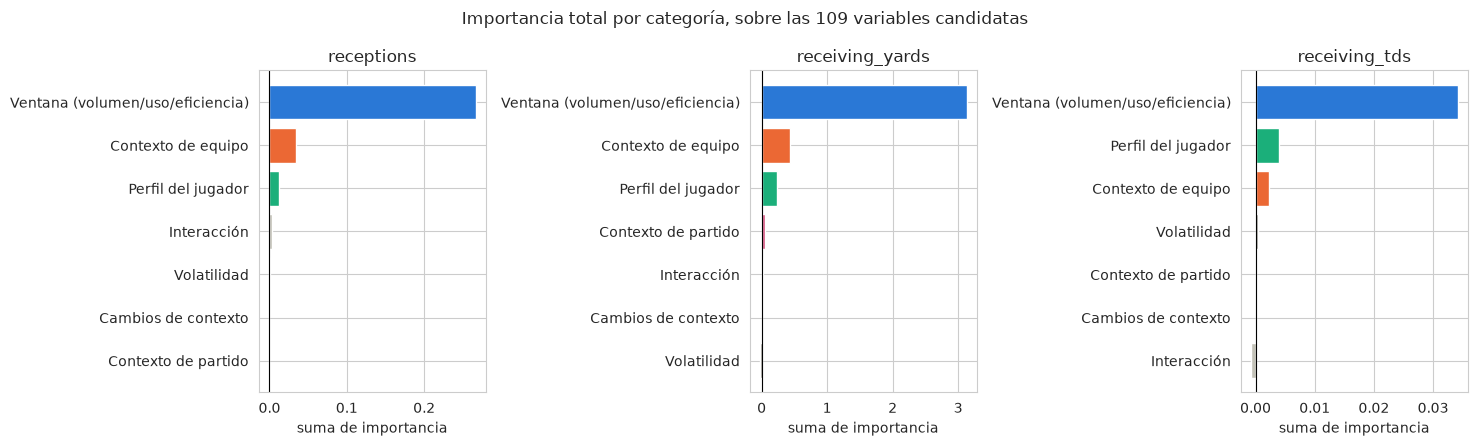

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, target in zip(axes, TARGETS):
    valores = resumen_categoria[target].sort_values()
    colores = [colores_categoria[c] for c in valores.index]
    ax.barh(valores.index, valores.values, color=colores)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(target)
    ax.set_xlabel("suma de importancia")
fig.suptitle("Importancia total por categoría, sobre las 109 variables candidatas")
plt.tight_layout()
plt.show()

**Cada panel tiene su propia escala**, a propósito: con la misma escala, el panel de `receiving_tds`
se vería plano (sus valores son hasta 100 veces menores), y esa diferencia de magnitud ya es un
hallazgo. Dentro de cada panel: **Ventana** domina en los tres; **Contexto de equipo** (casi solo
`depth_team`) es segundo en recepciones y yardas, y en touchdowns lo supera **Perfil del jugador**.
**Volatilidad**, **Cambios de contexto**, **Contexto de partido** e **Interacción** quedan cerca de
cero en los tres.

Ahora las variables individuales top 10 de cada target, coloreadas por su categoría — la misma
información de la tabla de 4.2, pero de un vistazo, y mostrando que dentro de "Ventana" no todas
las variables valen lo mismo.

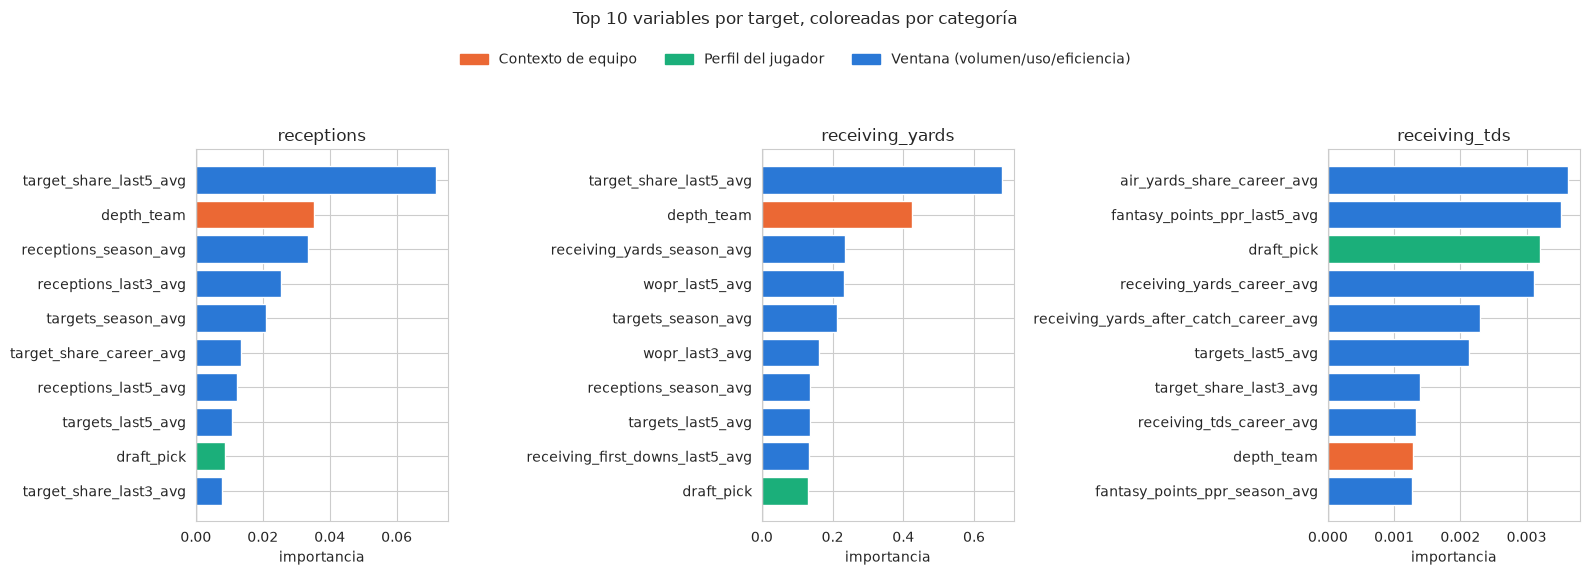

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, target in zip(axes, TARGETS):
    top = resultados[target].head(10).sort_values()
    colores = [colores_categoria[categoria(c)] for c in top.index]
    ax.barh(top.index, top.values, color=colores)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(target)
    ax.set_xlabel("importancia")

categorias_presentes = sorted({categoria(c) for t in TARGETS for c in resultados[t].head(10).index})
handles = [plt.Rectangle((0, 0), 1, 1, color=colores_categoria[c]) for c in categorias_presentes]
fig.legend(handles, categorias_presentes, loc="upper center", ncol=len(categorias_presentes),
           bbox_to_anchor=(0.5, 1.08), frameon=False)
fig.suptitle("Top 10 variables por target, coloreadas por categoría", y=1.14)
plt.tight_layout()
plt.show()

En los tres resultados, el top 10 sale casi por completo de **Ventana**. `depth_team` es la única
variable de **Contexto de equipo** que aparece, y `draft_pick` (**Perfil del jugador**) entra al top
10 de los tres. Ninguna variable de volatilidad, cambios de contexto, contexto de partido o
interacción aparece en ningún top 10.

## 5. `last3` vs. `last5` vs. `season` vs. `career` — con evidencia de modelo, en los 3 targets

Esto es lo que `2.5_eda_multivariable.ipynb` dejó abierto a propósito: la correlación aislada
mostraba a `last3` como la más débil de las 4, por un margen pequeño (2-3 puntos), insuficiente
para decidir. Aquí se suma la importancia de todas las variables de cada ventana, para cada
target — la pregunta ya no es "cuál correlaciona más sola" sino "cuál aporta más una vez que el
modelo ya tiene acceso a las demás".

In [15]:
resumen_ventanas = {}
for suf, nombre in [("_last3_avg", "last3"), ("_last5_avg", "last5"), ("_season_avg", "season"), ("_career_avg", "career")]:
    fila = {}
    for target in TARGETS:
        cols = [c for c in X.columns if c.endswith(suf)]
        fila[target] = resultados[target][cols].sum()
    resumen_ventanas[nombre] = fila

pd.DataFrame(resumen_ventanas).T.round(3)

,receptions,receiving_yards,receiving_tds
last3,0.057,0.600,0.004
last5,0.100,1.492,0.007
season,0.082,0.865,0.009
career,0.027,0.185,0.014


En recepciones y yardas gana `last5` (0.100 y 1.492), seguida de `season` (0.082 y 0.865), después
`last3` (0.057 y 0.600) y al final `career` (0.027 y 0.185). En touchdowns el orden se invierte:
`career` (0.014), `season` (0.009), `last5` (0.007) y `last3` (0.004), todas en magnitudes muy
pequeñas; probablemente, en un evento raro, el historial largo distingue mejor a quienes anotan con
regularidad.

**Decisión**: ninguna ventana se descarta. La selección (sección 4.2) toma las variables
individuales que están entre las 15 más importantes de algún resultado, sin importar su ventana.

## 6. El resto de las variables nuevas — resultado honesto, no solo las que funcionaron

In [16]:
otras = ["depth_team", "draft_pick", "edad", "anios_experiencia",
         "receiving_yards_volatilidad5", "targets_volatilidad5",
         "cambio_qb_titular_num", "cambio_equipo_num", "rest", "div_game",
         "target_share_x_ofensiva_equipo", "draft_pick_x_experiencia", "cambio_qb_x_target_share"]
tabla_otras = pd.DataFrame({t: resultados[t].reindex(otras) for t in TARGETS})
tabla_otras.round(4)

,receptions,receiving_yards,receiving_tds
depth_team,0.0352,0.4253,0.0013
draft_pick,0.0088,0.1309,0.0032
edad,0.0028,0.0881,0.0006
anios_experiencia,0.0001,0.0146,0.0001
receiving_yards_volatilidad5,-0.0012,-0.0422,-0.0000
targets_volatilidad5,0.0017,0.0173,0.0004
cambio_qb_titular_num,0.0000,0.0000,0.0000
cambio_equipo_num,0.0000,0.0000,0.0000
rest,-0.0011,0.0132,-0.0001
div_game,-0.0002,-0.0009,-0.0000


- **`depth_team`** resulta de las variables más fuertes en recepciones y yardas (2º lugar en las
  dos): el lugar de un receptor en la alineación de su equipo importa. Entra a la selección. En esta
  evaluación le falta el dato de 2025 (sección 2); la unificación de
  [`1.3_unificacion_alineaciones.ipynb`](1.3_unificacion_alineaciones.ipynb) lo completa para el
  modelado.
- **`draft_pick`** confirma con evidencia de modelo lo que sugería el análisis exploratorio: entra.
  **`edad`** y **`anios_experiencia`** se agregan por regla, porque
  [`2.3_eda_general.ipynb`](2.3_eda_general.ipynb) mostró una relación no lineal con los tres
  resultados que un corte por importancia puede no captar; `edad` además está entre las 15 más
  importantes de yardas (0.088), mientras que `anios_experiencia` sola aporta poco (0.015).
- **La volatilidad reciente** (desviación estándar de las últimas 5 apariciones) aporta poco o nada:
  la mayor es 0.017 en yardas (`targets_volatilidad5`), contra 0.679 de `target_share_last5_avg`, y
  `receiving_yards_volatilidad5` sale negativa. No entra.
- **Ninguna de las 3 interacciones** muestra un aporte claro: la mayor es 0.023 en yardas
  (`cambio_qb_x_target_share`) y `target_share_x_ofensiva_equipo` sale negativa en yardas. No entran.
- **Cambio de QB titular y cambio de equipo** no aportan nada medible una vez que el modelo tiene las
  variables de uso reciente. El efecto de un cambio de QB que se vio en
  [`2.5_eda_multivariable.ipynb`](2.5_eda_multivariable.ipynb) probablemente ya se refleja en la
  caída de uso del receptor. No entran.
- **`rest` y `div_game`** aportan muy poco (`rest` 0.013 en yardas, `div_game` cerca de cero). No
  entran.

## 7. Tabla final: variable, qué es, evidencia y decisión

La evidencia es la importancia por permutación de esta corrida (yardas · recepciones · touchdowns).
La decisión es la que tomaron las 34 variables que usan los modelos (sección 4.2).

| Categoría | Variable | Qué es | Evidencia (yardas · recepciones · TDs) | Decisión |
|---|---|---|---|---|
| Ventana | `target_share`/`wopr`/`air_yards_share`/`receiving_epa` (`last5`/`season`) | Qué tanto del trabajo de pase del equipo recae en el jugador (participación y eficiencia) | `target_share_last5_avg`: 0.679 · 0.072 · −0.000 | **Incluir, prioritarias** |
| Ventana | `fantasy_points_ppr` (`last3`/`last5`/`season`) | Puntos de fantasy (PPR) de la semana: resume el desempeño en un número | `last5`: 0.080 · 0.001 · 0.0035 | Incluir |
| Ventana | `receiving_first_downs` (`last5`) | Recepciones que lograron un primero y diez | 0.133 · −0.002 · 0.0005 | Incluir |
| Ventana | `air_yards_share` (`season`/`career`) | Parte de las yardas aéreas del equipo que van al jugador | `season`: 0.089 · 0.006 · 0.0009; `career`: 0.010 · −0.000 · 0.0036 | Incluir |
| Ventana | `receiving_air_yards` | Yardas que viajó el balón en el aire hacia el jugador | `last5`: 0.081 · 0.001 · 0.0004 | Incluir (en las 34, la versión `season`) |
| Ventana | `receiving_epa` (`last3`) | Puntos esperados que agregan sus recepciones | 0.064 · 0.005 · 0.0000 | Incluir |
| Ventana | `receiving_10`/`16`/`20` | Recepciones de 10, 16 o 20 yardas o más | Fuera de las 15 más importantes en esta corrida | En las 34 por la corrida anterior (sección 4.2) |
| Ventana | `catch_rate` (`career`), `receiving_tds` (`season`) | Porcentaje de envíos atrapados; touchdowns propios, rezagados | TDs: 0.0012 y 0.0011 | Incluir, aporte marginal en TDs |
| Ventana | Ventana `last3` | Promedio de los últimos 3 partidos | Menos que `last5`/`season` en recepciones y yardas; la menor en TDs (sección 5) | Incluir las que están entre las 15 más importantes |
| Ventana | Ventana `career` | Promedio de toda la carrera | La más débil en recepciones y yardas; la más fuerte en TDs (sección 5) | Incluir las que están entre las 15 más importantes |
| Ventana | `target_share`/`air_yards_share`/`wopr` juntas en Ridge | Las 3 miden participación, muy correlacionadas entre sí | Colinealidad 0.82-0.97 (`2.5_eda_multivariable.ipynb`) | Usar `columnas_por_modelo("ridge")` |
| Contexto de equipo | `depth_team` | Lugar en la alineación de su equipo (1 = titular) | 0.425 · 0.035 · 0.0013; 2º lugar en yardas y recepciones | **Incluir**; aquí sin el dato de 2025 (sección 2) |
| Perfil del jugador | `draft_pick` | Número de selección en el draft (al no drafteado se le asigna peor que el último pick real) | 0.131 · 0.009 · 0.0032 | Incluir |
| Perfil del jugador | `edad` / `anios_experiencia` (+ `_sq`/`_bucket` para lineales) | Edad esa temporada / temporadas en la NFL | 0.088 / 0.015 · ~0 · ~0 | Incluir por regla; transformación no lineal para Ridge |
| Ventana | `racr_acotado` | Eficiencia de conversión de yardas aéreas, con tope para valores extremos | Sin destacar | Se mantiene calculado, sin evidencia de aporte fuerte |
| Volatilidad | `_volatilidad5` | Qué tan irregular fue en sus últimas 5 apariciones | `receiving_yards`: −0.042 · −0.001 · −0.000; `targets`: 0.017 · 0.002 · 0.0004 | **No incluir** |
| Cambios de contexto | `cambio_qb_titular` / `cambio_equipo` | Si cambió el QB titular o el equipo del jugador | 0 · 0 · 0 | No incluir |
| Interacción | `target_share_x_ofensiva_equipo`, `draft_pick_x_experiencia`, `cambio_qb_x_target_share` | Combinaciones de dos variables existentes | −0.009 / 0.005 / 0.023 en yardas; cerca de cero en el resto | No incluir |
| Contexto de partido | Dureza defensiva del rival, clima, acarreos de WR | Defensa rival; temperatura y viento; jugadas de carrera de un WR | Sin efecto en el análisis exploratorio (2.3 a 2.5) | No incluir |
| Contexto de partido | Total implícito de las líneas de apuestas | Puntos que las casas de apuestas esperan que anote el equipo | Correlación de 0.088 con las yardas (2.3); no se evaluó en esta selección | Candidata para la selección pendiente |
| Contexto de partido | `rest` / `div_game` | Días de descanso / partido contra un rival de la misma división | `rest` 0.013 en yardas; el resto cerca de cero | No incluir |
| — | Filas sin ningún pase dirigido esa semana (`targets == 0`) | — | Afecta la función de pérdida (`2.2_eda_perfil_variables.ipynb`), no qué columnas usar | Se decide en la etapa de modelado |

Versión compacta, la misma que el docstring de `weekly/wr/src/features.py`:

| Variable | Decisión | Evidencia |
|---|---|---|
| `target_share`/`wopr`/`air_yards_share`/`receiving_epa`/`fantasy_points_ppr`/`receiving_first_downs` (`last5`/`season`) | Incluir, prioritarias | Las de mayor importancia (secciones 4.2 y 5) |
| Resto de columnas de uso/rendimiento | Incluir las que están entre las 15 más importantes de algún resultado | Sección 4.2 |
| Ventanas `last3` y `career` | Incluir las que están entre las 15 más importantes | `last3` aporta menos que `last5`/`season`; `career` es la más débil en recepciones y yardas y la más fuerte en touchdowns (sección 5) |
| `target_share`/`air_yards_share`/`wopr` juntas en Ridge | Usar `columnas_por_modelo("ridge")` | Colinealidad 0.82-0.97 (`2.5_eda_multivariable.ipynb`) |
| `depth_team` | Incluir | 2º lugar en yardas y recepciones (sección 4.2); unificada en `1.3_unificacion_alineaciones.ipynb` |
| `draft_pick` | Incluir (imputado: peor pick real + 1) | Entre las 15 más importantes de los tres resultados (sección 4.2) |
| `edad` / `anios_experiencia` (+ `_sq`/`_bucket` para lineales) | Incluir por regla | Relación no lineal (`2.3_eda_general.ipynb`); transformación específica para Ridge |
| `racr_acotado` | Se mantiene calculado, sin evidencia fuerte | No destacó en la evaluación conjunta |
| Volatilidad reciente (`_volatilidad5`) | No incluir | Importancia nula o muy pequeña (sección 6) |
| `cambio_qb_titular` / `cambio_equipo` | No incluir | Sin aporte medible con el uso reciente presente (sección 6) |
| Interacciones | No incluir | Sin aporte claro, una negativa en yardas (sección 6) |
| Dureza defensiva del rival, clima, acarreos de WR | No incluir | Sin efecto en el análisis exploratorio |
| Total implícito de las líneas de apuestas | Pendiente | Correlación de 0.088 con las yardas (2.3); candidata para la selección pendiente |
| `rest` / `div_game` | No incluir | Aporte mínimo (sección 6) |
| Filas sin ningún pase dirigido (`targets == 0`) | Se decide en la etapa de modelado | Afecta la función de pérdida, no qué columnas usar |

## Cierre

- Las variables que más aportan son de uso reciente del receptor (`target_share`, `wopr`, `targets` y
  `receptions` en `last5` y `season`), su lugar en la alineación (`depth_team`) y su perfil
  (`draft_pick`, `edad`). En touchdowns todo pesa poco, con las ventanas de carrera arriba.
- `last5` y `season` son las ventanas que más aportan en recepciones y yardas; `career`, en
  touchdowns. Ninguna se descarta.
- La volatilidad reciente, las tres interacciones, los cambios de QB o de equipo, `rest` y `div_game`
  se probaron y no aportan: no entran.
- La regla de selección (unión de las 15 más importantes de cada resultado) es inestable: con el dato
  de alineaciones corregido daría 31 variables en lugar de las 34 que usan los modelos. Se mantienen
  las 34 y la selección se rehará con otro método (sección 4.2).

Anterior: [`3.1_ingenieria_features.ipynb`](3.1_ingenieria_features.ipynb) · Siguiente:
[`4.1_preparacion_y_metricas.ipynb`](4.1_preparacion_y_metricas.ipynb)